# Import Libraries

In [1]:
# Import necessary libraries
import sqlite3
from sqlite3 import Error

import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

import kagglehub
import csv
import os

# Import the Dataset into the Database

In [2]:
# Download the dataset
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

# Connect to the SQLite database
conn = sqlite3.connect('image.db')

# Drop the test_images table if it exists
conn.execute(
                '''
                    DROP TABLE IF EXISTS test_images
                '''
)

# Drop the train_images table if it exists
conn.execute(
                '''
                    DROP TABLE IF EXISTS train_images
                '''
)

# Create the images table
conn.execute(
                '''
                    CREATE TABLE IF NOT EXISTS train_images(
                        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
                        image_name TEXT NOT NULL,
                        image_label INTEGER NOT NULL
                    )
                '''
            )

# Create the test_images table
conn.execute(
                '''
                    CREATE TABLE IF NOT EXISTS test_images(
                        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
                        image_name TEXT NOT NULL
                    )
                '''
            )

# Import the dataset into the database and create a list of labels
training_labels = []
# Import the training images
train_path = os.path.join(path, 'train.csv')
with open(train_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        image_name = row[1]
        image_label = row[2]
        training_labels.append(image_label)
        if not image_name or not image_label: # Skip if image_name or image_label is empty
            continue
        conn.execute(
            '''
                INSERT INTO train_images (image_name, image_label)
                VALUES (?, ?)
            ''',
            (image_name, image_label)
        )
        
# Import the test images
test_path = os.path.join(path, 'test.csv')
with open(test_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        if not image_name: # Skip if image_name is empty
            continue
        image_name = row[0]
        conn.execute(
            '''
                INSERT INTO test_images (image_name)
                VALUES (?)
            ''',
            (image_name,)
        )

# Commit the changes and close the connection
conn.commit()
conn.close()

# Data Augmentation

# Create Data Pipelines

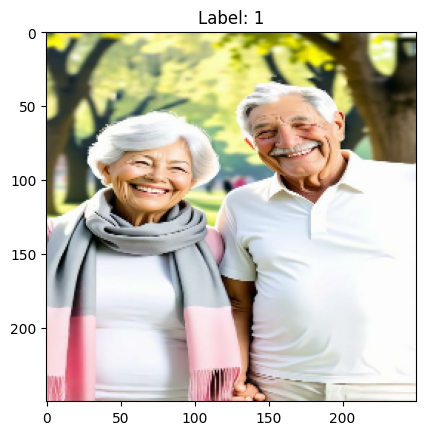

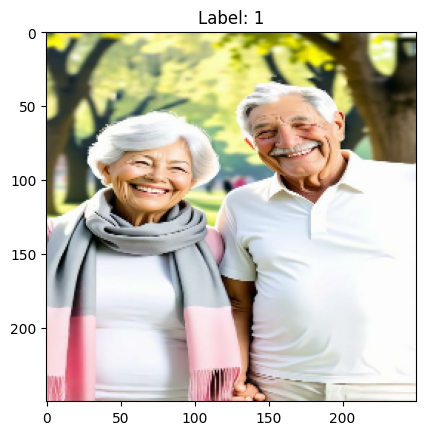

In [ ]:
# Set the GPU memory growth to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    
# Setup train dataset
train_df = pd.read_csv(train_path)
train_paths = train_df['file_name'].values
train_labels = train_df['label'].values
train_images = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))

# Setup test dataset
test_df = pd.read_csv(test_path)
test_paths = test_df['id'].values
test_images = tf.data.Dataset.from_tensor_slices((test_paths))

# Read the image data
def read_image(data):
    image_file = data[0].numpy().decode("utf-8")
    
    # If there is no label (train set), set label to None
    try:
        label = data[1].numpy()
    except IndexError:
        label = None

    image = tf.io.read_file(os.path.join(path, image_file))
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [250, 250])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Iterate through the dataset and display images
for image_data in train_images.take(10):
    try:
        image, label = read_image(image_data)
        plt.imshow(image.numpy())
        plt.title(f'Label: {label if label is not None else "None"}')
        plt.show()
    except Exception as e:
        print(f"Error processing image: {e}")


# Define Model

In [ ]:
model = keras.Sequential

# Compile Model

# Train Model

# Test with Test Data

# Predictions

In [ ]:
# Add Gui

# Reporting and Visualizations